<a href="https://colab.research.google.com/github/anshubilawliya230456-web/ML-Lab/blob/main/Logistic_Reg_Loan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv('/content/sample_data/loan_data.csv')

print("Dataset Preview:")
print(df.head())

Dataset Preview:
   person_age person_gender person_education  person_income  person_emp_exp  \
0        22.0        female           Master        71948.0               0   
1        21.0        female      High School        12282.0               0   
2        25.0        female      High School        12438.0               3   
3        23.0        female         Bachelor        79753.0               0   
4        24.0          male           Master        66135.0               1   

  person_home_ownership  loan_amnt loan_intent  loan_int_rate  \
0                  RENT    35000.0    PERSONAL          16.02   
1                   OWN     1000.0   EDUCATION          11.14   
2              MORTGAGE     5500.0     MEDICAL          12.87   
3                  RENT    35000.0     MEDICAL          15.23   
4                  RENT    35000.0     MEDICAL          14.27   

   loan_percent_income  cb_person_cred_hist_length  credit_score  \
0                 0.49                         3.

In [5]:
df = df.apply(lambda x: pd.factorize(x)[0] if x.dtype == 'object' else x)

In [6]:
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

In [7]:
def normalize(X):
    mins = np.min(X, axis=0)
    maxs = np.max(X, axis=0)
    rng = maxs - mins
    rng[rng == 0] = 1
    return (X - mins) / rng

X = normalize(X)

In [8]:
X = np.hstack((np.ones((X.shape[0], 1)), X))

In [9]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [10]:
def cost(beta, X, y):
    m = len(y)
    h = sigmoid(np.dot(X, beta))

    h = np.clip(h, 1e-10, 1 - 1e-10)

    return -(1/m) * np.sum(y*np.log(h) + (1-y)*np.log(1-h))

In [11]:
def gradient_descent(X, y, lr=0.1, iterations=1000):
    m, n = X.shape
    beta = np.zeros(n)

    for i in range(iterations):
        h = sigmoid(np.dot(X, beta))
        gradient = (1/m) * np.dot(X.T, (h - y))
        beta -= lr * gradient

        if i % 100 == 0:
            print(f"Iteration {i}, Cost: {cost(beta, X, y)}")

    return beta

In [12]:
beta = gradient_descent(X, y)

print("Final Weights:", beta)

Iteration 0, Cost: 0.6697156995134934
Iteration 100, Cost: 0.42060857756875925
Iteration 200, Cost: 0.3755335347903355
Iteration 300, Cost: 0.3497661148072623
Iteration 400, Cost: 0.3331624532865231
Iteration 500, Cost: 0.32147537254781533
Iteration 600, Cost: 0.3127136889481563
Iteration 700, Cost: 0.30583895279802836
Iteration 800, Cost: 0.3002592412528093
Iteration 900, Cost: 0.2956120270202524
Final Weights: [-0.61989749 -0.07472497 -0.05133314 -0.11271533 -0.04537597 -0.06429401
 -1.34365482  0.30257675  0.31385232  1.38937078  1.19561807 -0.15449445
 -0.5942244  -3.37401725]


In [13]:
def predict(X, beta):
    probs = sigmoid(np.dot(X, beta))
    return (probs >= 0.5).astype(int)

y_pred = predict(X, beta)

In [14]:
accuracy = np.mean(y_pred == y) * 100
print("Accuracy:", accuracy, "%")

Accuracy: 87.41555555555556 %


In [15]:
if X.shape[1] == 3:
    x0 = X[y == 0]
    x1 = X[y == 1]

    plt.scatter(x0[:,1], x0[:,2], c='blue', label='Class 0')
    plt.scatter(x1[:,1], x1[:,2], c='red', label='Class 1')

    x1_line = np.linspace(0, 1, 100)
    x2_line = -(beta[0] + beta[1]*x1_line) / beta[2]

    plt.plot(x1_line, x2_line, 'k-', label='Decision Boundary')
    plt.legend()
    plt.show()

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def loadCSV(filename):
    # ✅ Proper CSV loading
    df = pd.read_csv(filename)

    print("Original Dataset:")
    print(df.head())

    # ✅ Convert categorical → numeric
    df = df.apply(lambda x: pd.factorize(x)[0] if x.dtype == 'object' else x)

    dataset = df.values

    print("Dataset shape:", dataset.shape)

    return dataset


def normalize(X):
    mins = np.min(X, axis=0)
    maxs = np.max(X, axis=0)
    rng = maxs - mins
    rng[rng == 0] = 1
    return (X - mins) / rng


def logistic_func(beta, X):
    return 1.0 / (1 + np.exp(-np.dot(X, beta.T)))


def log_gradient(beta, X, y):
    y = y.reshape(-1, 1)
    error = logistic_func(beta, X) - y
    return np.dot(error.T, X) / X.shape[0]


def cost_func(beta, X, y):
    y_pred = logistic_func(beta, X)
    y_pred = np.clip(y_pred, 1e-10, 1 - 1e-10)

    y = y.reshape(-1, 1)

    return np.mean(-(y*np.log(y_pred) + (1-y)*np.log(1-y_pred)))


def train(X, y, beta, lr=0.1, iterations=1000):
    for i in range(iterations):
        beta = beta - lr * log_gradient(beta, X, y)

        if i % 100 == 0:
            print(f"Iteration {i}, Cost: {cost_func(beta, X, y)}")

    return beta


def pred_values(beta, X):
    probs = logistic_func(beta, X)
    return (probs >= 0.5).astype(int).flatten()


def plot_reg(X, y, beta):
    x_0 = X[y == 0]
    x_1 = X[y == 1]

    plt.scatter(x_0[:, 1], x_0[:, 2], c='blue', label='Class 0')
    plt.scatter(x_1[:, 1], x_1[:, 2], c='red', label='Class 1')

    x1 = np.linspace(0, 1, 100)
    x2 = -(beta[0,0] + beta[0,1]*x1) / beta[0,2]

    plt.plot(x1, x2, 'k-', label='Decision Boundary')
    plt.legend()
    plt.show()


if __name__ == "__main__":

    # 🔥 correct path (after upload in Colab)
    dataset = loadCSV('/content/sample_data/loan_data.csv')

    # features
    X = normalize(dataset[:, :-1])

    # add bias
    X = np.hstack((np.ones((X.shape[0], 1)), X))

    # labels
    y = dataset[:, -1]

    # initialize beta
    beta = np.zeros((1, X.shape[1]))

    # train
    beta = train(X, y, beta)

    print("\nFinal beta:", beta)

    # prediction
    y_pred = pred_values(beta, X)

    print("Correct predictions:", np.sum(y == y_pred))
    print("Accuracy:", np.mean(y == y_pred) * 100, "%")

    # plot if 2 features
    if X.shape[1] == 3:
        plot_reg(X, y, beta)

Original Dataset:
   person_age person_gender person_education  person_income  person_emp_exp  \
0        22.0        female           Master        71948.0               0   
1        21.0        female      High School        12282.0               0   
2        25.0        female      High School        12438.0               3   
3        23.0        female         Bachelor        79753.0               0   
4        24.0          male           Master        66135.0               1   

  person_home_ownership  loan_amnt loan_intent  loan_int_rate  \
0                  RENT    35000.0    PERSONAL          16.02   
1                   OWN     1000.0   EDUCATION          11.14   
2              MORTGAGE     5500.0     MEDICAL          12.87   
3                  RENT    35000.0     MEDICAL          15.23   
4                  RENT    35000.0     MEDICAL          14.27   

   loan_percent_income  cb_person_cred_hist_length  credit_score  \
0                 0.49                         3

Dataset shape: (45000, 14)
Beta: [-0.61989749 -0.07472497 -0.05133314 -0.11271533 -0.04537597 -0.06429401
 -1.34365482  0.30257675  0.31385232  1.38937078  1.19561807 -0.15449445
 -0.5942244  -3.37401725]
Accuracy: 87.41555555555556 %


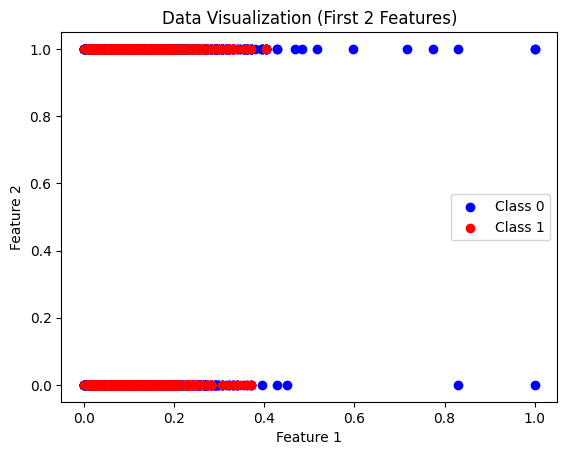

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# =========================
# LOAD DATA
# =========================
df = pd.read_csv('/content/sample_data/loan_data.csv')

# convert categorical to numeric
df = df.apply(lambda x: pd.factorize(x)[0] if x.dtype == 'object' else x)

print("Dataset shape:", df.shape)


# =========================
# SPLIT DATA
# =========================
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values


# =========================
# NORMALIZE
# =========================
def normalize(X):
    mins = np.min(X, axis=0)
    maxs = np.max(X, axis=0)
    rng = maxs - mins
    rng[rng == 0] = 1
    return (X - mins) / rng

X = normalize(X)


# =========================
# ADD BIAS
# =========================
X = np.hstack((np.ones((X.shape[0], 1)), X))


# =========================
# SIGMOID
# =========================
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


# =========================
# TRAIN
# =========================
def train(X, y, lr=0.1, iterations=1000):
    m, n = X.shape
    beta = np.zeros(n)

    for i in range(iterations):
        h = sigmoid(np.dot(X, beta))
        gradient = (1/m) * np.dot(X.T, (h - y))
        beta -= lr * gradient

    return beta


# =========================
# TRAIN MODEL
# =========================
beta = train(X, y)

print("Beta:", beta)


# =========================
# PREDICTION
# =========================
def predict(X, beta):
    probs = sigmoid(np.dot(X, beta))
    return (probs >= 0.5).astype(int)

y_pred = predict(X, beta)

print("Accuracy:", np.mean(y_pred == y) * 100, "%")


# =========================
# GRAPH (WORKS FOR ANY DATASET)
# =========================
# we use only first 2 features for visualization

X_plot = X[:, 1:3]   # take first 2 features (ignore bias)

x0 = X_plot[y == 0]
x1 = X_plot[y == 1]

plt.scatter(x0[:, 0], x0[:, 1], c='blue', label='Class 0')
plt.scatter(x1[:, 0], x1[:, 1], c='red', label='Class 1')

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Data Visualization (First 2 Features)")
plt.legend()
plt.show()

Dataset shape: (45000, 14)
Selected Features: Index(['previous_loan_defaults_on_file', 'loan_percent_income'], dtype='object')
Final Beta: [-1.21260247 -5.18126783  4.20654094]


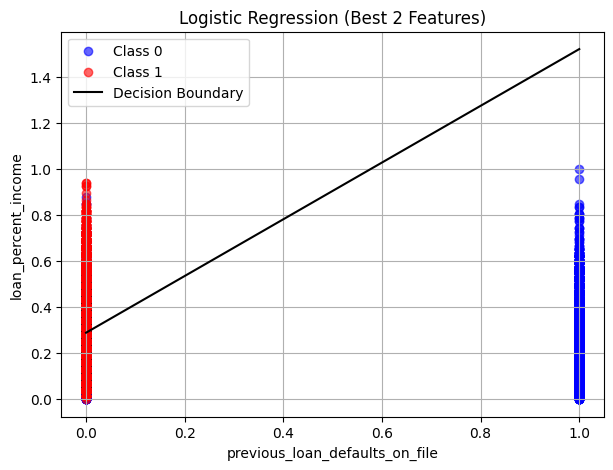

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# =========================
# LOAD DATA
# =========================
df = pd.read_csv('/content/sample_data/loan_data.csv')

# convert categorical to numeric
df = df.apply(lambda x: pd.factorize(x)[0] if x.dtype == 'object' else x)

print("Dataset shape:", df.shape)


# =========================
# SELECT BEST 2 FEATURES
# =========================
correlation = df.corr().abs()

# select top 2 features most correlated with target
top_features = correlation.iloc[:-1, -1].sort_values(ascending=False).index[:2]

print("Selected Features:", top_features)

X = df[top_features].values
y = df.iloc[:, -1].values


# =========================
# NORMALIZE
# =========================
def normalize(X):
    mins = np.min(X, axis=0)
    maxs = np.max(X, axis=0)
    rng = maxs - mins
    rng[rng == 0] = 1
    return (X - mins) / rng

X = normalize(X)


# =========================
# ADD BIAS
# =========================
X = np.hstack((np.ones((X.shape[0], 1)), X))


# =========================
# SIGMOID
# =========================
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


# =========================
# TRAIN MODEL
# =========================
def train(X, y, lr=0.5, iterations=1000):
    m, n = X.shape
    beta = np.zeros(n)

    for i in range(iterations):
        h = sigmoid(np.dot(X, beta))
        gradient = (1/m) * np.dot(X.T, (h - y))
        beta -= lr * gradient

    return beta


beta = train(X, y)

print("Final Beta:", beta)


# =========================
# PLOT GRAPH (FINAL OUTPUT)
# =========================
X_plot = X[:, 1:]

x0 = X_plot[y == 0]
x1 = X_plot[y == 1]

plt.figure(figsize=(7,5))

plt.scatter(x0[:, 0], x0[:, 1], c='blue', label='Class 0', alpha=0.6)
plt.scatter(x1[:, 0], x1[:, 1], c='red', label='Class 1', alpha=0.6)

# decision boundary
x_vals = np.linspace(0, 1, 100)
y_vals = -(beta[0] + beta[1]*x_vals) / beta[2]

plt.plot(x_vals, y_vals, 'k-', label='Decision Boundary')

plt.xlabel(top_features[0])
plt.ylabel(top_features[1])
plt.title("Logistic Regression (Best 2 Features)")
plt.legend()
plt.grid()

plt.show()

Continuous features: ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt', 'loan_intent', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score']
Selected Features: Index(['loan_percent_income', 'loan_int_rate'], dtype='object')
Final Beta: [-3.88327827  4.75575626  3.62207686]


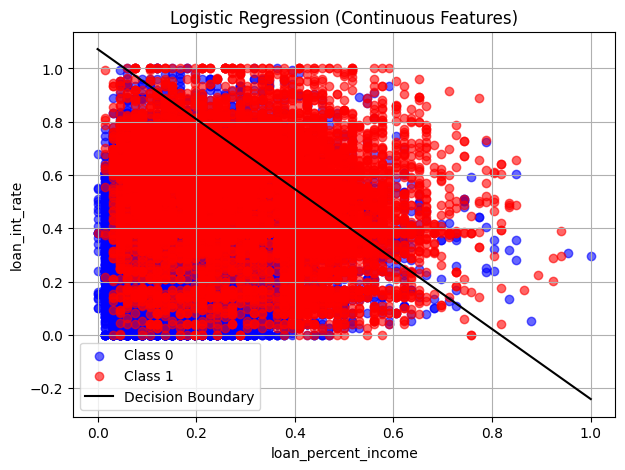

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# =========================
# LOAD DATA
# =========================
df = pd.read_csv('/content/sample_data/loan_data.csv')

# convert categorical to numeric
df = df.apply(lambda x: pd.factorize(x)[0] if x.dtype == 'object' else x)


# =========================
# REMOVE BINARY FEATURES
# =========================
continuous_cols = []

for col in df.columns[:-1]:  # exclude target
    if df[col].nunique() > 5:   # keep only continuous features
        continuous_cols.append(col)

df_cont = df[continuous_cols + [df.columns[-1]]]

print("Continuous features:", continuous_cols)


# =========================
# SELECT BEST 2 FEATURES
# =========================
correlation = df_cont.corr().abs()

top_features = correlation.iloc[:-1, -1].sort_values(ascending=False).index[:2]

print("Selected Features:", top_features)


X = df_cont[top_features].values
y = df_cont.iloc[:, -1].values


# =========================
# NORMALIZE
# =========================
def normalize(X):
    mins = np.min(X, axis=0)
    maxs = np.max(X, axis=0)
    rng = maxs - mins
    rng[rng == 0] = 1
    return (X - mins) / rng

X = normalize(X)


# =========================
# ADD BIAS
# =========================
X = np.hstack((np.ones((X.shape[0], 1)), X))


# =========================
# SIGMOID
# =========================
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


# =========================
# TRAIN MODEL
# =========================
def train(X, y, lr=0.5, iterations=1000):
    m, n = X.shape
    beta = np.zeros(n)

    for _ in range(iterations):
        h = sigmoid(np.dot(X, beta))
        gradient = (1/m) * np.dot(X.T, (h - y))
        beta -= lr * gradient

    return beta


beta = train(X, y)

print("Final Beta:", beta)


# =========================
# PLOT GRAPH (LIKE GITHUB)
# =========================
X_plot = X[:, 1:]

x0 = X_plot[y == 0]
x1 = X_plot[y == 1]

plt.figure(figsize=(7,5))

plt.scatter(x0[:, 0], x0[:, 1], c='blue', label='Class 0', alpha=0.6)
plt.scatter(x1[:, 0], x1[:, 1], c='red', label='Class 1', alpha=0.6)

# decision boundary
x_vals = np.linspace(0, 1, 100)
y_vals = -(beta[0] + beta[1]*x_vals) / beta[2]

plt.plot(x_vals, y_vals, 'k-', label='Decision Boundary')

plt.xlabel(top_features[0])
plt.ylabel(top_features[1])
plt.title("Logistic Regression (Continuous Features)")
plt.legend()
plt.grid()

plt.show()